In [55]:
import os 
import time 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy.special import j0
import plotly.graph_objects as go
from iminuit.cost import LeastSquares
from scipy.integrate import fixed_quad

In [56]:
save_folder = 'run8'

n = 5

lower_factor = 0.99
upper_factor = 2 - lower_factor

b_max = 30
q_max = 0.2



In [57]:
# Load experimental data
atlas_data = pd.read_csv('../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
totem_data = pd.read_csv('../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)

# Function to process data for each experiment
def process_data(data, energy_blocks):
    x_values = []
    y_values = []
    y_errors = []
    
    for start, end in energy_blocks:
        block = data.iloc[start:end] if end is not None else data.iloc[start:]
        x_values.append(block[0].values)
        y_values.append(block[1].values)
        y_errors.append(block[2].values)
    
    return x_values, y_values, y_errors

# Energy ranges for each experiment (7TeV, 8TeV, 13TeV)
atlas_blocks = [(0, 29), (29, 58), (58, None)]
totem_blocks = [(0, 65), (65, 118), (118, None)]

# Process data
x_atlas, y_atlas, yerr_atlas = process_data(atlas_data, atlas_blocks)
x_totem, y_totem, yerr_totem = process_data(totem_data, totem_blocks)

# Extract values by energy (index 0=7TeV, 1=8TeV, 2=13TeV)
x_7_atlas, y_7_atlas, yerr_7_atlas = x_atlas[0], y_atlas[0], yerr_atlas[0]
x_8_atlas, y_8_atlas, yerr_8_atlas = x_atlas[1], y_atlas[1], yerr_atlas[1]
x_13_atlas, y_13_atlas, yerr_13_atlas = x_atlas[2], y_atlas[2], yerr_atlas[2]


/tmp/ipykernel_12262/2977988099.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  atlas_data = pd.read_csv('../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
/tmp/ipykernel_12262/2977988099.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  totem_data = pd.read_csv('../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)


In [58]:

b_0 = (33 - 6) / (12 * np.pi)
Lambda = 0.284  # ΛQCD in GeV
gamma_1 = 0.084
gamma_2 = 2.36
rho = 4.0
s0 = 1.0
alpha_prime = 0.25



ensemble_parameters = {
    'atlas': {
        'log': {
            'eps': 0.0753,
            'mg': 0.356,
            'a1': 1.373,
            'a2': 2.50
        },
        'pl': {
            'eps': 0.0753,
            'mg': 0.421,
            'a1': 1.517,
            'a2': 2.05
        }
    }
}


# Get parameters for selected configuration
initial_params_log_atlas = ensemble_parameters['atlas']['log']
initial_params_pl_atlas = ensemble_parameters['atlas']['pl']



In [59]:
def m2_log(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return mg ** 2 * ratio ** (-1 - gamma_1)

def m2_pl(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return (mg ** 4 / (q2 + mg ** 2)) * ratio ** (gamma_2 - 1)


def G_p(q2, a1, a2):
    return np.exp(-(a1 * q2 + a2 * q2 ** 2))

def alpha_D(q2, mg, m2_func):
    m2 = m2_func(q2, mg)
    return 1.0 / (b_0 * (q2 + m2) * np.log((q2 + 4 * m2) / (Lambda ** 2)))

def T_1(k, phi, mg, a1, a2, m2_func, q):
    q2 = q ** 2
    qk_cos = q * k * np.cos(phi)
    qk_plus_squared = q2 / 4 + qk_cos + k ** 2
    qk_minus_squared = q2 / 4 - qk_cos + k ** 2
    alpha_D_plus = alpha_D(qk_plus_squared, mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)
    G0 = G_p(q2, a1, a2)
    return alpha_D_plus * alpha_D_minus * G0 ** 2

def T_2(k, phi, mg, a1, a2, m2_func, q):
    q2 = q ** 2
    qk_cos = q * k * np.cos(phi)
    qk_plus_squared = q2 / 4 + qk_cos + k ** 2
    qk_minus_squared = q2 / 4 - qk_cos + k ** 2
    alpha_D_plus = alpha_D(qk_plus_squared, mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)
    factor = q2 + 9 * abs(k ** 2 - q2 / 4)
    G0 = G_p(q2, a1, a2)
    G_minus = G_p(factor, a1, a2)
    return alpha_D_plus * alpha_D_minus * G_minus * (2 * G0 - G_minus)

def born_sigma_tot(amp_value, s):
    return amp_value.imag / s * 0.389379323

def born_amp(diff_T, s, epsilon, t):
    
    alpha_pomeron = 1.0 + epsilon + 0.25 * t

    first_term = s**(alpha_pomeron)
    second_term = 1/(1**(alpha_pomeron-1))
    
    regge_factor = first_term * second_term
    return 1j * 8.0 * regge_factor * diff_T


In [60]:
import numpy as np

# Trapezoid rule (vectorized)
def trapezoid(func, a, b, n):
    """
    Computes the integral of a function using the trapezoid rule.
    This version is vectorized with NumPy for performance.
    """
    if n == 0:
        return 0.0
    x = np.linspace(a, b, n + 1)
    y = func(x)
    h = (b - a) / n
    return h * (np.sum(y) - 0.5 * (y[0] + y[-1]))

# Adaptive trapezoid (vectorized and efficient)
def adaptive_trapezoid(func, a, b, tol=1e-6, max_iter=20):
    """
    Computes the integral of a function using an adaptive trapezoid method.
    It increases the number of points until the desired tolerance is met.
    This version is optimized to avoid re-computing function values and is vectorized.
    """
    if a == b:
        return 0.0

    # Start with 1 interval (2 points)
    n = 1
    h = b - a
    integral = (func(a) + func(b)) * h / 2.0

    for i in range(1, max_iter):
        n *= 2
        h /= 2.0
        
        # Add contributions from new midpoints
        x_new = a + h * np.arange(1, n, 2)
        integral_new = np.sum(func(x_new)) * h
        
        prev_integral = integral
        integral = integral / 2.0 + integral_new
        
        if abs(integral - prev_integral) < tol:
            return integral
    
    # Optional: You can add a warning if convergence is not reached
    # print(f"Warning: Did not converge to tolerance {tol} within {max_iter} iterations.")
    return integral

# Complex version (no changes needed)
def adaptive_trapezoid_complex(func, a, b, tol=1e-6):
    """
    Computes the integral of a complex function by integrating
    the real and imaginary parts separately using the adaptive trapezoid method.
    This function will automatically use the optimized `adaptive_trapezoid`.
    """
    real_part = adaptive_trapezoid(lambda x: np.real(func(x)), a, b, tol)
    imag_part = adaptive_trapezoid(lambda x: np.imag(func(x)), a, b, tol)
    return real_part + 1j * imag_part

In [61]:
from numpy.polynomial.legendre import leggauss
import numpy as np

# It is assumed that the functions T_1 and T_2 are defined elsewhere
# in your notebook and can handle vectorized inputs (NumPy arrays).

def compute_2d_integral_gauss(sqrt_s_val, mg, a1, a2, m2_func, q, n_k=50, n_phi=50):
    """
    Computes the 2D integral over k and phi using Gauss-Legendre quadrature.

    This optimized version:
    - Merges the separate k and phi integration functions into one.
    - Uses np.einsum for a concise and potentially faster final summation.
    - Allows for different numbers of sample points for k and phi integrals.
    """
    # Nodes and weights for k integration over [0, sqrt_s_val]
    x_k, w_k = leggauss(n_k)
    k = 0.5 * (x_k + 1) * sqrt_s_val
    w_k_mapped = w_k * 0.5 * sqrt_s_val

    # Nodes and weights for phi integration over [0, 2*pi]
    x_phi, w_phi = leggauss(n_phi)
    phi = (x_phi + 1) * np.pi  # Map [-1,1] -> [0, 2*pi]
    w_phi_mapped = w_phi * np.pi  # Adjust weights for the interval change

    # Create a 2D grid of points for vectorized evaluation.
    # k_grid will have shape (n_k, 1) and phi_grid will have shape (1, n_phi).
    # NumPy broadcasting will then create a (n_k, n_phi) grid for the integrand.
    k_grid = k[:, np.newaxis]
    phi_grid = phi[np.newaxis, :]

    # Evaluate the integrand on the entire grid.
    # The integrand is k * (T_1 - T_2).
    integrand_grid = k_grid * (T_1(k_grid, phi_grid, mg, a1, a2, m2_func, q) -
                               T_2(k_grid, phi_grid, mg, a1, a2, m2_func, q))

    # Perform the weighted sum over both dimensions using einsum.
    # 'ij,i,j->' computes sum_{i,j} (integrand_grid_{ij} * w_k_mapped_{i} * w_phi_mapped_{j})
    total_integral = np.einsum('ij,i,j->', integrand_grid, w_k_mapped, w_phi_mapped)

    return total_integral

# Your previous two functions can now be replaced by a single call to this new function.
# For example, a call like:
# compute_k_phi_integral_vec(sqrt_s, mg, a1, a2, m2, q, n=100)
#
# would become:
# compute_2d_integral_gauss(sqrt_s, mg, a1, a2, m2, q, n_k=100, n_phi=100)

In [ ]:
import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy.special import j0

def compute_eikonal_amplitude(sqrt_s_values, b_max, q_max, born_amp_value, n_b=80, n_q=80):
    """
    Computes the eikonal amplitude by performing a 2D integral over b and q.

    This optimized version:
    - Replaces the two separate functions with a single, fully vectorized function.
    - Eliminates all Python loops by using NumPy broadcasting to compute the
      integrals for all `sqrt_s` and `b` values simultaneously.
    - Uses np.einsum for clear and efficient weighted summation.
    - Allows for different numbers of sample points for the b and q integrals.
    """
    # Ensure sqrt_s_values is a NumPy array for vectorization.
    # Also, check if the original input was a scalar to format the output correctly.
    is_scalar_input = np.isscalar(sqrt_s_values)
    sqrt_s_values = np.atleast_1d(sqrt_s_values)
    s = sqrt_s_values**2

    # Gauss-Legendre nodes and weights for b integration over [0, b_max]
    xb, wb = leggauss(n_b)
    b_nodes = 0.5 * (xb + 1) * b_max
    wb_mapped = wb * 0.5 * b_max

    # Gauss-Legendre nodes and weights for q integration over [0, q_max]
    xq, wq = leggauss(n_q)
    q_nodes = 0.5 * (xq + 1) * q_max
    wq_mapped = wq * 0.5 * q_max

    # Create 2D grids for b and q to compute the chi(b) integral for all b values at once.
    # b_grid will have shape (n_b, 1) and q_grid will have shape (1, n_q).
    b_grid = b_nodes[:, np.newaxis]
    q_grid = q_nodes[np.newaxis, :]

    # --- Step 1: Compute the chi(b) integral over q for all b nodes ---
    # The integrand for chi is (q * j0(b*q) * born_amp) / s.
    # We first compute the integral part, which is independent of s.
    # The result of j0(b_grid * q_grid) will be broadcast to shape (n_b, n_q).
    chi_integrand = q_grid * j0(b_grid * q_grid) * born_amp_value

    # Integrate over q using einsum. The notation 'bq,q->b' means:
    # for each b, sum the product of the (b,q) integrand with the q weight.
    # The result has shape (n_b,).
    chi_integral_part = np.einsum('bq,q->b', chi_integrand, wq_mapped)

    # Now, create the full chi_vals(s, b) by dividing by s.
    # This broadcasts s (Ns,) and chi_integral_part (n_b,) to a grid of shape (Ns, n_b).
    chi_vals = chi_integral_part / s[:, np.newaxis]

    # --- Step 2: Compute the eikonal amplitude integral over b ---
    # The integrand is b * (1 - exp(1j * chi)).
    # This broadcasts b_nodes (n_b,) and chi_vals (Ns, n_b) to shape (Ns, n_b).
    eik_integrand = b_nodes * (1 - np.exp(1j * chi_vals))

    # Integrate over b using einsum. The notation 'sb,b->s' means:
    # for each s, sum the product of the (s,b) integrand with the b weight.
    # The result has shape (Ns,).
    b_integral_result = np.einsum('sb,b->s', eik_integrand, wb_mapped)

    # --- Step 3: Calculate the final amplitude ---
    A_eik = 1j * s * b_integral_result


    # Return a scalar if the input was a scalar, otherwise a list to match original behavior.
    if is_scalar_input:
        return A_eik[0]
    else:  
      return A_eik.tolist()

In [63]:
def differential_sigma(amp_value, s):
    amp_squared = amp_value.imag * amp_value.imag
    denominator = (16 * np.pi * s**2)
    return amp_squared / denominator * 0.389379323

In [64]:
import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy.special import j0

# It is assumed that the following functions are defined elsewhere in your notebook:
# - m2_log(k, phi, mg, a1, a2)
# - m2_pl(k, phi, mg, a1, a2)
# - T_1(k, phi, mg, a1, a2, m2_func, q)
# - T_2(k, phi, mg, a1, a2, m2_func, q)
# - born_amp(diff_T, s, eps, t)
# - differential_sigma(eik_amplitudes, s)
# For this vectorized code to work, these functions (especially T_1, T_2, and born_amp)
# must be able to handle multi-dimensional NumPy arrays as inputs.

def optimized_model_function(x_born, eps, mg, a1, a2, sqrt_s,
                             model_type='log',
                             q_integration_points=np.linspace(0, 0.1, 100),
                             b_max=5.0, q_max=2.0, # Max limits for eikonal integrals
                             n_k=50, n_phi=50, n_b=80, n_q=80):
    """
    Calculates the differential cross-section using a fully vectorized approach.

    This function replaces the previous `model_function` and eliminates all Python
    loops for a significant performance increase.

    Args:
        x_born: Array of experimental q^2 values.
        eps, mg, a1, a2: Model parameters.
        sqrt_s: Center-of-mass energy.
        model_type: 'log' or 'pl' for the m2 function.
        q_integration_points: Points for the outer trapezoidal integration.
        b_max, q_max: Integration limits for the eikonal amplitude calculation.
        n_k, n_phi, n_b, n_q: Number of Gauss-Legendre points for each integral dimension.
    """
    m2_func = m2_log if model_type == 'log' else m2_pl
    s = sqrt_s ** 2

    # --- Part 1: Compute diff_T = integral over q, k, and phi ---
    # This section computes the 3D integral for diff_T in a single vectorized operation.

    # 1a. Set up nodes and weights for the k and phi Gauss-Legendre integrals.
    x_k, w_k = leggauss(n_k)
    k_nodes = 0.5 * (x_k + 1) * sqrt_s
    w_k_mapped = w_k * 0.5 * sqrt_s

    x_phi, w_phi = leggauss(n_phi)
    phi_nodes = (x_phi + 1) * np.pi
    w_phi_mapped = w_phi * np.pi

    # 1b. Create a 3D grid for k, phi, and the outer q integration points.
    k_grid = k_nodes[:, np.newaxis, np.newaxis]
    phi_grid = phi_nodes[np.newaxis, :, np.newaxis]
    q_grid_outer = q_integration_points[np.newaxis, np.newaxis, :]

    # 1c. Evaluate the T integrand on the full 3D grid.
    integrand_T = k_grid * (T_1(k_grid, phi_grid, mg, a1, a2, m2_func, q_grid_outer) -
                            T_2(k_grid, phi_grid, mg, a1, a2, m2_func, q_grid_outer))

    # 1d. Integrate over k and phi to get T_vals for each outer q point.
    T_vals = np.einsum('kpq,k,p->q', integrand_T, w_k_mapped, w_phi_mapped)

    # 1e. Integrate the resulting T_vals over the outer q points.
    diff_T = np.trapezoid(T_vals, q_integration_points)

    # --- Part 2: Compute Born amplitudes for each experimental point ---
    t_vals = -np.array(x_born)
    born_amplitudes = born_amp(diff_T, s, eps, t_vals)

    # --- Part 3: Compute Eikonal amplitudes (vectorized over all Born amplitudes) ---
    # This replaces the loop over `born_amplitudes`.

    # 3a. Set up nodes and weights for the b and q eikonal integrals.
    xb, wb = leggauss(n_b)
    b_nodes = 0.5 * (xb + 1) * b_max
    wb_mapped = wb * 0.5 * b_max

    xq, wq = leggauss(n_q)
    q_nodes_eik = 0.5 * (xq + 1) * q_max
    wq_mapped_eik = wq * 0.5 * q_max

    # 3b. Create grids for b, q_eik, and the different Born amplitudes.
    b_grid = b_nodes[:, np.newaxis, np.newaxis]
    q_grid_eik = q_nodes_eik[np.newaxis, :, np.newaxis]
    born_grid = born_amplitudes[np.newaxis, np.newaxis, :]

    # 3c. Calculate the chi(b) integral over q for all b-nodes and Born amplitudes.
    chi_integrand = q_grid_eik * j0(b_grid * q_grid_eik) * born_grid
    chi_integral_part = np.einsum('bqB,q->bB', chi_integrand, wq_mapped_eik)
    chi_vals = chi_integral_part / s

    # 3d. Calculate the eikonal integral over b for all Born amplitudes.
    eik_integrand = b_nodes[:, np.newaxis] * (1 - np.exp(1j * chi_vals))
    b_integral_result = np.einsum('bB,b->B', eik_integrand, wb_mapped)
    eik_amplitudes = 1j * s * b_integral_result

    # --- Part 4: Compute final differential cross section ---
    diff_sigma = differential_sigma(eik_amplitudes, s)

    return diff_sigma

In [65]:
def make_least_squares(x, y, yerr, energy, model_type):
    return LeastSquares(x, y, yerr, 
        lambda x, eps, mg, a1, a2: optimized_model_function(x, eps, mg, a1, a2, energy, model_type))

# Direct calculation without extra functions
total_cost_log_atlas = (
    make_least_squares(x_7_atlas, y_7_atlas, yerr_7_atlas, 7000, 'log') +
    make_least_squares(x_8_atlas, y_8_atlas, yerr_8_atlas, 8000, 'log') +
    make_least_squares(x_13_atlas, y_13_atlas, yerr_13_atlas, 13000, 'log')
)

total_cost_pl_atlas = (
    make_least_squares(x_7_atlas, y_7_atlas, yerr_7_atlas, 7000, 'pl') +
    make_least_squares(x_8_atlas, y_8_atlas, yerr_8_atlas, 8000, 'pl') +
    make_least_squares(x_13_atlas, y_13_atlas, yerr_13_atlas, 13000, 'pl')
)


In [66]:
def otimization(total_cost_func, initial_params, model_type: str, ensemble: str):
    print('\n')
    print(80 * '-')
    print(f"Iniciando otimização dos parâmetros usando LeastSquares para {model_type} em {ensemble.upper()}")

    start_time = time.time()
    
    m = Minuit(total_cost_func, 
               eps=initial_params['eps'],
               mg=initial_params['mg'],
               a1=initial_params['a1'],
               a2=initial_params['a2'])

    if model_type == 'pl':
        # Configurações adicionais
        down = 0.80
        up = 2 - down

        m.limits['mg'] = (down * initial_params['mg'], up *initial_params['mg'])
        m.limits['eps'] = (down * initial_params['eps'], up *initial_params['eps'])
        m.limits['a2'] = (down * initial_params['a2'], up * initial_params['a2'])
        m.limits['a1'] = (down * initial_params['a1'], up * initial_params['a1'])

        # Configurações adicionais
        m.strategy = 2
        m.errordef = 1
        m.tol = 1e-4

        ncall = 10000


        print('simplex...')
        print(80*'-')
        m.simplex(ncall=ncall)

        print('migrad 1 ...')
        print(80*'-')
        m.migrad(ncall=ncall)

        # print('migrad 2 ...')
        # print(80*'-')
        # m.migrad(ncall=ncall)

        print('hesse...')
        print(80*'-')
        m.hesse(ncall=ncall)

        # print('minos...')
        # print(80*'-')
        # m.minos(cl = 0.9)


    else:
        down = 0.94
        up = 2- down

        m.limits['mg'] = (down * initial_params['mg'], up * initial_params['mg'])
        # m.limits['eps'] = (down * initial_params['epsilon'], up * initial_params['epsilon'])
        m.limits['a2'] = (down * initial_params['a2'], up * initial_params['a2'])
        # m.limits['a1'] = (down * initial_params['a1'], up * initial_params['a1'])

        # Configurações adicionais
        m.strategy = 2
        m.errordef = 7.79
        m.tol = 1e-2
         
        m.migrad(ncall=70)
        m.hesse(ncall=10)

    print(f'Finalizado a minimização para {model_type} em {ensemble}')

    execution_time = time.time() - start_time
    
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f'Tempo de execução para {model_type} em {ensemble}: {minutes} min {seconds:.2f} s \n')
    
    print(f"Parâmetros otimizados para {model_type} em {ensemble}: \n")
    print(f'mg: {m.values["mg"]} ± {m.errors["mg"]}')
    print(f'eps: {m.values["eps"]} ± {m.errors["eps"]}')
    print(f'a1: {m.values["a1"]} ± {m.errors["a1"]}')
    print(f'a2: {m.values["a2"]} ± {m.errors["a2"]}')
    print(f'chi2/ndof: {m.fval / m.ndof}')


    return m



In [67]:
m_pl_atlas = otimization(total_cost_pl_atlas,
                         initial_params_pl_atlas, 'pl', 'atlas')


/home/victor/miniconda3/envs/two_gluon/lib/python3.13/site-packages/iminuit/minuit.py:139: ErrordefAlreadySetWarning: cost function has an errordef attribute equal to 1.0, you should not override this with Minuit.errordef
  warnings.warn(msg, ErrordefAlreadySetWarning)




--------------------------------------------------------------------------------
Iniciando otimização dos parâmetros usando LeastSquares para pl em ATLAS
simplex...
--------------------------------------------------------------------------------
migrad 1 ...
--------------------------------------------------------------------------------
hesse...
--------------------------------------------------------------------------------
Finalizado a minimização para pl em atlas
Tempo de execução para pl em atlas: 0 min 11.65 s 

Parâmetros otimizados para pl em atlas: 

mg: 0.33680309724365476 ± 0.16202857256900247
eps: 0.09035999868215604 ± 0.0301086618150613
a1: 1.2136040657245954 ± 0.4668184882359565
a2: 1.6400000004810456 ± 0.501326642983627
chi2/ndof: 1701.7059061607733


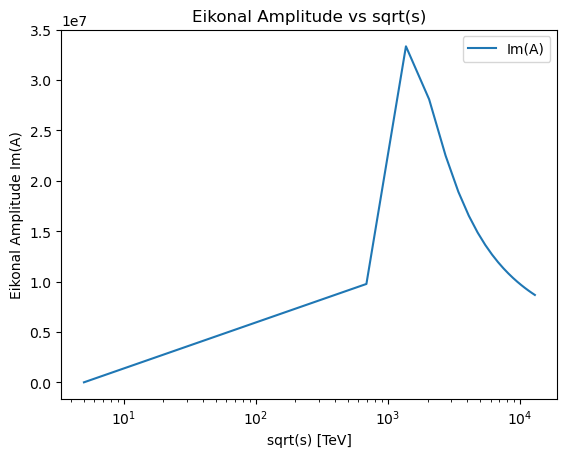

In [78]:
eps = m_pl_atlas.values['eps']
mg = m_pl_atlas.values['mg']
a1 = m_pl_atlas.values['a1']
a2 = m_pl_atlas.values['a2']
model_type = 'pl'
m2_func = m2_pl
q_integration_points = np.linspace(0, 0.1, 500)
b_max = 30
q_max = 0.2
n_k = 50
n_phi = 50
n_b = 80
n_q = 80

def compute_diff_T(sqrt_s):
    s = sqrt_s ** 2
    x_k, w_k = leggauss(n_k)
    k_nodes = 0.5 * (x_k + 1) * sqrt_s
    w_k_mapped = w_k * 0.5 * sqrt_s
    x_phi, w_phi = leggauss(n_phi)
    phi_nodes = (x_phi + 1) * np.pi
    w_phi_mapped = w_phi * np.pi
    k_grid = k_nodes[:, np.newaxis, np.newaxis]
    phi_grid = phi_nodes[np.newaxis, :, np.newaxis]
    q_grid_outer = q_integration_points[np.newaxis, np.newaxis, :]
    integrand_T = k_grid * (T_1(k_grid, phi_grid, mg, a1, a2, m2_func, q_grid_outer) -
                            T_2(k_grid, phi_grid, mg, a1, a2, m2_func, q_grid_outer))
    T_vals = np.einsum('kpq,k,p->q', integrand_T, w_k_mapped, w_phi_mapped)
    diff_T = np.trapezoid(T_vals, q_integration_points)
    return diff_T

sqrt_s_vals = np.linspace(5, 13000, 20)
amplitudes = []
for sqrt_s in sqrt_s_vals:
    diff_T = compute_diff_T(sqrt_s)
    s = sqrt_s ** 2
    born_amp_value = born_amp(diff_T, s, eps, 0)
    A_eik = compute_eikonal_amplitude([sqrt_s], b_max, q_max, born_amp_value)[0]
    amplitudes.append(A_eik)

amplitudes = np.array(amplitudes)

plt.figure()
plt.plot(sqrt_s_vals, np.imag(amplitudes), label='Im(A)')
plt.xlabel('sqrt(s) [TeV]')
plt.xscale('log')
plt.ylabel('Eikonal Amplitude Im(A)')
plt.title('Eikonal Amplitude vs sqrt(s)')
plt.legend()
plt.show()

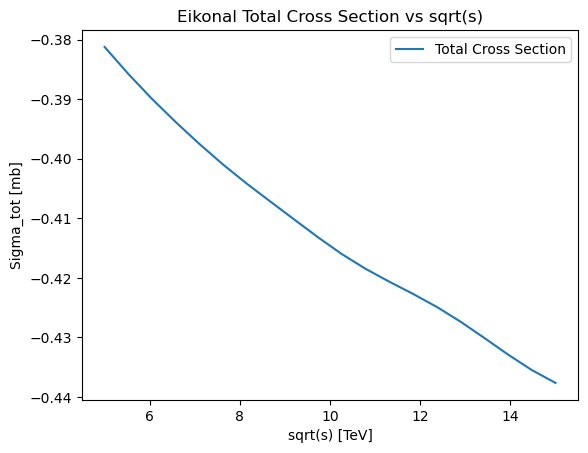

In [79]:
eps = m_pl_atlas.values['eps']
mg = m_pl_atlas.values['mg']
a1 = m_pl_atlas.values['a1']
a2 = m_pl_atlas.values['a2']
model_type = 'pl'
m2_func = m2_pl
q_integration_points = np.linspace(0, 0.1, 10)
b_max = 30
q_max = 0.2
n_k = 50
n_phi = 50
n_b = 80
n_q = 80

def sigma_tot_eik(s, amp):
    return (4*np.pi)/s * amp.imag * 0.389379323

def compute_diff_T(sqrt_s):
    s = sqrt_s ** 2
    x_k, w_k = leggauss(n_k)
    k_nodes = 0.5 * (x_k + 1) * sqrt_s
    w_k_mapped = w_k * 0.5 * sqrt_s
    x_phi, w_phi = leggauss(n_phi)
    phi_nodes = (x_phi + 1) * np.pi
    w_phi_mapped = w_phi * np.pi
    k_grid = k_nodes[:, np.newaxis, np.newaxis]
    phi_grid = phi_nodes[np.newaxis, :, np.newaxis]
    q_grid_outer = q_integration_points[np.newaxis, np.newaxis, :]
    integrand_T = k_grid * (T_1(k_grid, phi_grid, mg, a1, a2, m2_func, q_grid_outer) -
                            T_2(k_grid, phi_grid, mg, a1, a2, m2_func, q_grid_outer))
    T_vals = np.einsum('kpq,k,p->q', integrand_T, w_k_mapped, w_phi_mapped)
    diff_T = np.trapezoid(T_vals, q_integration_points)
    return diff_T

t_vals = np.linspace(0, -0.5, 50)
sqrt_s_vals = np.linspace(5, 15, 20)
sigma_tot_vals = []
for sqrt_s in sqrt_s_vals:
    diff_T = compute_diff_T(sqrt_s)
    s = sqrt_s ** 2
    born_amplitudes = born_amp(diff_T, s, eps, t_vals)
    eik_amplitudes = []
    for born in born_amplitudes:
        A_eik = compute_eikonal_amplitude([sqrt_s], b_max, q_max, born)[0]
        eik_amplitudes.append(A_eik)
    diff_sigmas = [differential_sigma(amp, s) for amp in eik_amplitudes]
    sigma_tot = np.trapezoid(diff_sigmas, t_vals)
    sigma_tot_vals.append(sigma_tot)

sigma_tot_vals = np.array(sigma_tot_vals)

plt.figure()
plt.plot(sqrt_s_vals, sigma_tot_vals, label='Total Cross Section')
plt.xlabel('sqrt(s) [TeV]')
plt.ylabel('Sigma_tot [mb]')
plt.title('Eikonal Total Cross Section vs sqrt(s)')
plt.legend()
plt.show()